In [1]:
import os

In [2]:
from langgraph.graph import StateGraph, START, END
from state import AgentState
from nodes.planner import plannerNode
from nodes.load_memory import loadMemoryNode
from nodes.retriever import retrieverNode
from nodes.responder import responderNode
from nodes.therapist import therapistNode
from nodes.update_memory import updateMemoryNode
from nodes.planRouter import planRouter
from nodes.load_memory_router import loadMemoryRouter

In [3]:
print(os.getcwd())

/Users/anand07/Documents/Projects/GenJournals/backend/app/agents


In [4]:
graph = StateGraph(AgentState)

graph.add_node('Planner', plannerNode)
graph.add_node('Retriever', retrieverNode)
graph.add_node('LoadMemory', loadMemoryNode)
graph.add_node('Therapist', therapistNode)
graph.add_node('Responder', responderNode)
graph.add_node('updateMemory', updateMemoryNode)


In [5]:
graph.add_edge(START, 'Planner')

In [5]:
graph.add_edge(START, 'Planner')
graph.add_edge('Planner', 'LoadMemory')
graph.add_conditional_edges('Planner',planRouter, {
    'END': END,
    'Retriever': 'Retriever'
} )
graph.add_edge('Retriever', 'Therapist')
graph.add_edge('Therapist', 'updateMemory')
graph.add_edge('updateMemory', END)
graph.add_conditional_edges('LoadMemory', loadMemoryRouter)
graph.add_edge('Responder', 'updateMemory')


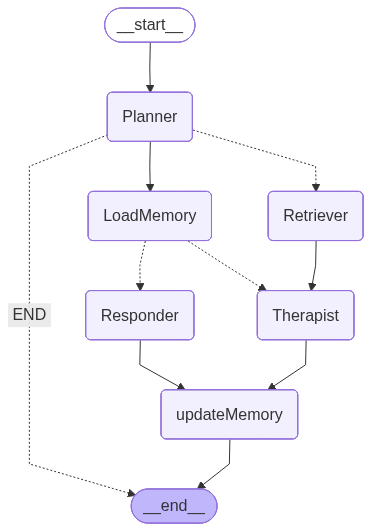

In [6]:
graph.compile()
